# Visual Insights Notebook

## Project

RetailOps Insight — Retail Operations Analytics, Data Quality, and Support Dashboard

## Purpose

This notebook creates visual summaries from SQL-generated outputs.

The goal is to turn KPI and SQL analysis results into clear business visuals that can support dashboard design, reporting, and GitHub portfolio presentation.

## Visuals Created

- Monthly completed sales trend
- Monthly net sales after cancellations
- Top countries by completed sales
- Top products by completed sales
- Data quality issue summary
- Customer ID coverage summary

In [3]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

In [4]:
current_dir = Path.cwd()

if current_dir.name == "notebooks":
    project_root = current_dir.parent
else:
    project_root = current_dir

sql_output_dir = project_root / "reports" / "sql_outputs"
figure_dir = project_root / "reports" / "figures"

figure_dir.mkdir(parents=True, exist_ok=True)

print("Current directory:", current_dir)
print("Project root:", project_root)
print("SQL output directory:", sql_output_dir)
print("Figure directory:", figure_dir)
print("SQL output directory exists:", sql_output_dir.exists())
print("Figure directory exists:", figure_dir.exists())

Current directory: /home/tirtha/Projects/retailops-insight/notebooks
Project root: /home/tirtha/Projects/retailops-insight
SQL output directory: /home/tirtha/Projects/retailops-insight/reports/sql_outputs
Figure directory: /home/tirtha/Projects/retailops-insight/reports/figures
SQL output directory exists: True
Figure directory exists: True


In [5]:
monthly_kpi = pd.read_csv(sql_output_dir / "monthly_kpi_summary.csv")
top_countries = pd.read_csv(sql_output_dir / "top_countries_by_sales.csv")
top_products = pd.read_csv(sql_output_dir / "top_products_by_sales.csv")
data_quality_issues = pd.read_csv(sql_output_dir / "data_quality_issue_summary.csv")
customer_coverage = pd.read_csv(sql_output_dir / "customer_id_coverage.csv")

print("Files loaded successfully.")
print("Monthly KPI shape:", monthly_kpi.shape)
print("Top countries shape:", top_countries.shape)
print("Top products shape:", top_products.shape)
print("Data quality issues shape:", data_quality_issues.shape)
print("Customer coverage shape:", customer_coverage.shape)

Files loaded successfully.
Monthly KPI shape: (13, 9)
Top countries shape: (10, 3)
Top products shape: (10, 5)
Data quality issues shape: (6, 2)
Customer coverage shape: (2, 3)


## Source Data Preview

This section previews the SQL-generated CSV outputs used for visual analysis.

In [6]:
monthly_kpi.head()

,invoice_year_month,total_transaction_lines,completed_transaction_lines,completed_invoice_count,completed_sales_amount,cancelled_amount,net_sales_after_cancellations,average_order_value,data_issue_rows
0,2010-12,42481,41480,1559,823746.14,74789.12,748957.02,528.38,203
1,2011-01,35147,34306,1086,691364.56,131364.30,560000.26,636.62,44
2,2011-02,27707,27105,1100,523631.89,25569.24,498062.65,476.03,79
3,2011-03,36748,35803,1454,717639.36,34372.28,683267.08,493.56,112
4,2011-04,29916,29096,1246,537808.62,44601.50,493207.12,431.63,75


In [7]:
top_countries.head()

,country,completed_transaction_lines,total_completed_sales
0,United Kingdom,485123,9025222.08
1,Netherlands,2359,285446.34
2,EIRE,7890,283453.96
3,Germany,9040,228867.14
4,France,8407,209715.11


In [8]:
top_products.head()

,stock_code,product_description,completed_transaction_lines,units_sold,total_completed_sales
0,DOT,DOTCOM POSTAGE,706,706,206248.77
1,22423,REGENCY CAKESTAND 3 TIER,2017,13879,174484.74
2,23843,"PAPER CRAFT , LITTLE BIRDIE",1,80995,168469.60
3,85123A,WHITE HANGING HEART T-LIGHT HOLDER,2265,37660,104518.80
4,47566,PARTY BUNTING,1706,18295,99504.33


In [9]:
data_quality_issues.head()

,issue_type,issue_count
0,Missing Customer ID,135080
1,Negative Quantity,10624
2,Duplicate Row,10147
3,Cancelled Invoice,9288
4,Zero or Negative Unit Price,2517


In [10]:
customer_coverage.head()

,customer_id_status,transaction_lines,completed_sales_amount
0,Known Customer ID,406829,8911407.90
1,Missing Customer ID,135080,1755276.64


## Monthly Completed Sales Trend

This chart shows completed sales amount by month.

Completed sales excludes cancelled/return rows and data issue rows.

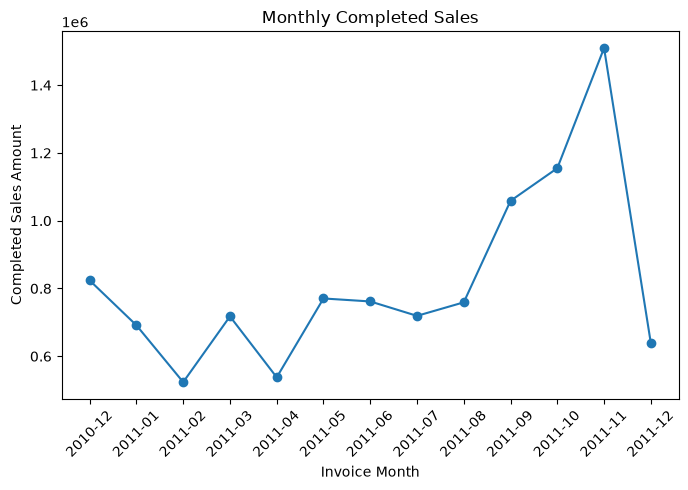

Saved chart to: /home/tirtha/Projects/retailops-insight/reports/figures/monthly_completed_sales.png


In [11]:
plt.figure(figsize=(7, 5))

plt.plot(
    monthly_kpi["invoice_year_month"],
    monthly_kpi["completed_sales_amount"],
    marker="o"
)

plt.title("Monthly Completed Sales")
plt.xlabel("Invoice Month")
plt.ylabel("Completed Sales Amount")
plt.xticks(rotation=45)
plt.tight_layout()

output_path = figure_dir / "monthly_completed_sales.png"
plt.savefig(output_path, dpi=150)

plt.show()

print(f"Saved chart to: {output_path}")

## Monthly Net Sales After Cancellations

This chart shows completed sales minus cancelled/return amount by month.

This gives a simplified view of net sales after cancellations.

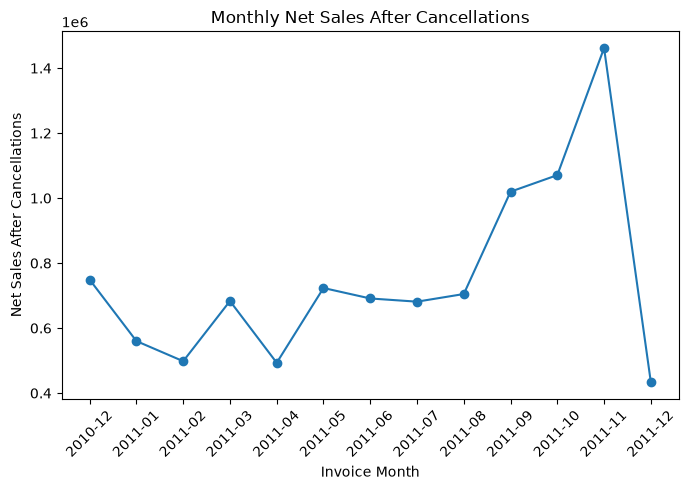

Saved chart to: /home/tirtha/Projects/retailops-insight/reports/figures/monthly_net_sales_after_cancellations.png


In [12]:
plt.figure(figsize=(7, 5))

plt.plot(
    monthly_kpi["invoice_year_month"],
    monthly_kpi["net_sales_after_cancellations"],
    marker="o"
)

plt.title("Monthly Net Sales After Cancellations")
plt.xlabel("Invoice Month")
plt.ylabel("Net Sales After Cancellations")
plt.xticks(rotation=45)
plt.tight_layout()

output_path = figure_dir / "monthly_net_sales_after_cancellations.png"
plt.savefig(output_path, dpi=150)

plt.show()

print(f"Saved chart to: {output_path}")

## Top Countries by Completed Sales

This chart shows the top countries ranked by completed sales amount.

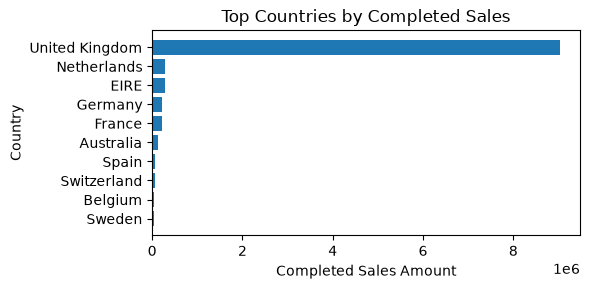

Saved chart to: /home/tirtha/Projects/retailops-insight/reports/figures/top_countries_by_sales.png


In [13]:
top_countries_plot = top_countries.sort_values(
    by="total_completed_sales",
    ascending=True
)

plt.figure(figsize=(6,3))

plt.barh(
    top_countries_plot["country"],
    top_countries_plot["total_completed_sales"]
)

plt.title("Top Countries by Completed Sales")
plt.xlabel("Completed Sales Amount")
plt.ylabel("Country")
plt.tight_layout()

output_path = figure_dir / "top_countries_by_sales.png"
plt.savefig(output_path, dpi=150)

plt.show()

print(f"Saved chart to: {output_path}")

## Top Products by Completed Sales

This chart shows the top products ranked by completed sales amount.

Product descriptions are shortened for readability.

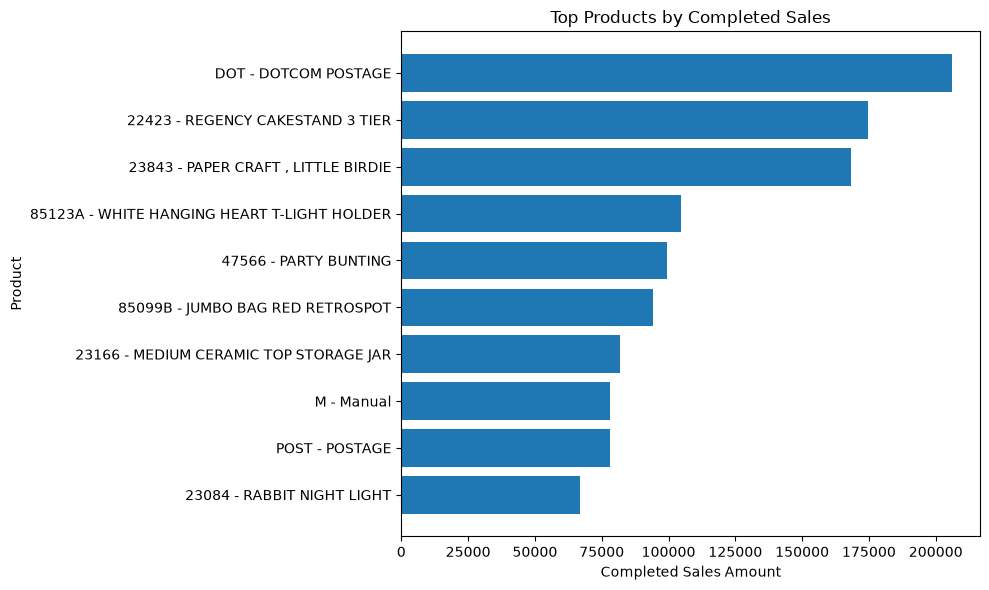

Saved chart to: /home/tirtha/Projects/retailops-insight/reports/figures/top_products_by_sales.png


In [15]:
top_products_plot = top_products.copy()

top_products_plot["product_label"] = (
    top_products_plot["stock_code"].astype(str)
    + " - "
    + top_products_plot["product_description"].astype(str).str.slice(0, 35)
)

top_products_plot = top_products_plot.sort_values(
    by="total_completed_sales",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_products_plot["product_label"],
    top_products_plot["total_completed_sales"]
)

plt.title("Top Products by Completed Sales")
plt.xlabel("Completed Sales Amount")
plt.ylabel("Product")
plt.tight_layout()

output_path = figure_dir / "top_products_by_sales.png"
plt.savefig(output_path, dpi=120)

plt.show()

print(f"Saved chart to: {output_path}")

## Data Quality Issue Summary

This chart shows the most common data quality issues identified during the cleaning process.

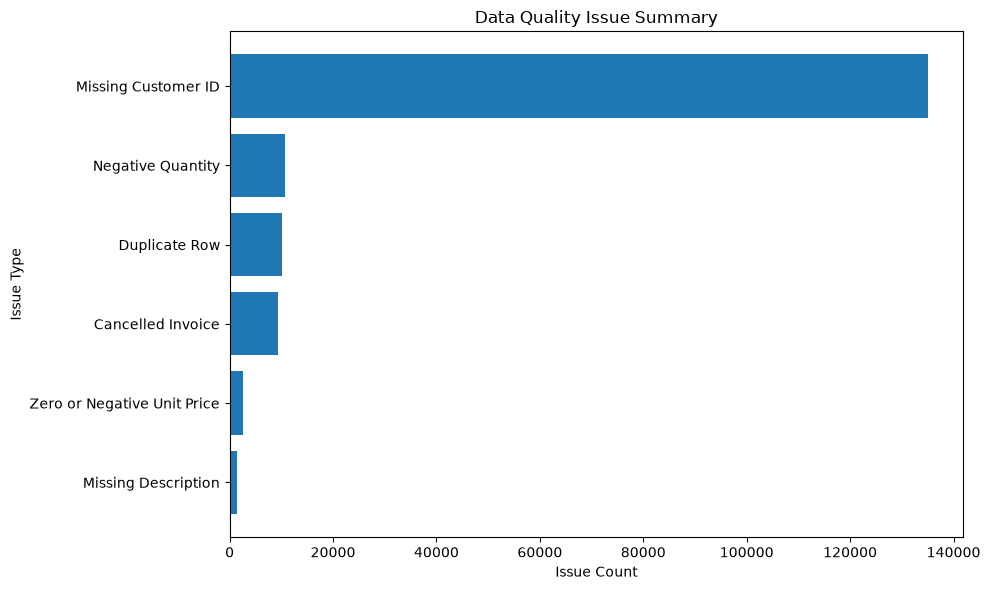

Saved chart to: /home/tirtha/Projects/retailops-insight/reports/figures/data_quality_issue_summary.png


In [16]:
data_quality_plot = data_quality_issues.sort_values(
    by="issue_count",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    data_quality_plot["issue_type"],
    data_quality_plot["issue_count"]
)

plt.title("Data Quality Issue Summary")
plt.xlabel("Issue Count")
plt.ylabel("Issue Type")
plt.tight_layout()

output_path = figure_dir / "data_quality_issue_summary.png"
plt.savefig(output_path, dpi=150)

plt.show()

print(f"Saved chart to: {output_path}")

## Customer ID Coverage

This chart compares completed sales amount linked to known customer IDs versus missing customer IDs.

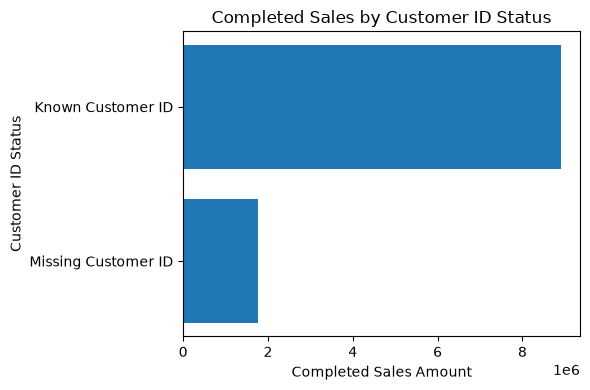

Saved chart to: /home/tirtha/Projects/retailops-insight/reports/figures/completed_sales_by_customer_id_status.png


In [19]:
customer_coverage_plot = customer_coverage.sort_values(
    by="completed_sales_amount",
    ascending=True
)

plt.figure(figsize=(6, 4))

plt.barh(
    customer_coverage_plot["customer_id_status"],
    customer_coverage_plot["completed_sales_amount"]
)

plt.title("Completed Sales by Customer ID Status")
plt.xlabel("Completed Sales Amount")
plt.ylabel("Customer ID Status")
plt.tight_layout()

output_path = figure_dir / "completed_sales_by_customer_id_status.png"
plt.savefig(output_path, dpi=120)

plt.show()

print(f"Saved chart to: {output_path}")

## Chart Inventory

This section lists the chart files generated by this notebook.

In [20]:
chart_files = sorted(figure_dir.glob("*.png"))

chart_inventory = pd.DataFrame({
    "chart_file": [file.name for file in chart_files],
    "path": [str(file.relative_to(project_root)) for file in chart_files]
})

chart_inventory

,chart_file,path
0,completed_sales_by_customer_id_status.png,reports/figures/completed_sales_by_customer_id...
1,data_quality_issue_summary.png,reports/figures/data_quality_issue_summary.png
2,monthly_completed_sales.png,reports/figures/monthly_completed_sales.png
3,monthly_net_sales_after_cancellations.png,reports/figures/monthly_net_sales_after_cancel...
4,top_countries_by_sales.png,reports/figures/top_countries_by_sales.png
5,top_products_by_sales.png,reports/figures/top_products_by_sales.png
